In [2]:
import os
import random
import shutil

def make_subset(src_dir, dst_dir, per_class=200, seed=42):
    """
    Create a balanced subset of images from a multi-class dataset.

    Parameters:
        src_dir (str): Path to original dataset (e.g., 'flower_photos')        dst_dir (str): Path to new subset folder (e.g., 'subset_200')
        per_class (int): Number of images to copy from each class
        seed (int): Random seed for reproducibility
    """
    random.seed(seed)

    # Create destination folder
    os.makedirs(dst_dir, exist_ok=True)

    # Get all class folders
    classes = [d for d in os.listdir(src_dir) if os.path.isdir(os.path.join(src_dir, d))]
    print(f"Found {len(classes)} classes: {classes}\n")

    # Copy per_class images from each class folder
    for cls in classes:
        src_cls_path = os.path.join(src_dir, cls)
        dst_cls_path = os.path.join(dst_dir, cls)
        os.makedirs(dst_cls_path, exist_ok=True)

        # Get all image files
        imgs = [f for f in os.listdir(src_cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Randomly sample images
        if len(imgs) < per_class:
            print(f"⚠️  Class '{cls}' has only {len(imgs)} images, copying all.")
            selected_imgs = imgs
        else:
            selected_imgs = random.sample(imgs, per_class)

        # Copy selected images
        for img in selected_imgs:
            src_path = os.path.join(src_cls_path, img)
            dst_path = os.path.join(dst_cls_path, img)
            shutil.copy2(src_path, dst_path)

        print(f"✅ Copied {len(selected_imgs)} images from class '{cls}'")

    # Final verification
    total = sum(len(files) for _, _, files in os.walk(dst_dir))
    print(f"\n✅ Subset creation complete.")
    print(f"➡️ {len(classes)} classes × {per_class} images each = {total} total images.")
    print(f"Subset saved at: {os.path.abspath(dst_dir)}")

# -------------------------
# Example usage
# -------------------------
if __name__ == "__main__":
    make_subset("flower_photos", "subset_200", per_class=200)


Found 5 classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

✅ Copied 200 images from class 'daisy'
✅ Copied 200 images from class 'dandelion'
✅ Copied 200 images from class 'roses'
✅ Copied 200 images from class 'sunflowers'
✅ Copied 200 images from class 'tulips'

✅ Subset creation complete.
➡️ 5 classes × 200 images each = 1000 total images.
Subset saved at: C:\Users\medha\subset_200


In [3]:
import os

root = "flower_photos"
for cls in sorted(os.listdir(root)):
    cls_path = os.path.join(root, cls)
    if os.path.isdir(cls_path):
        print(cls, len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]))

daisy 633
dandelion 898
roses 641
sunflowers 699
tulips 799


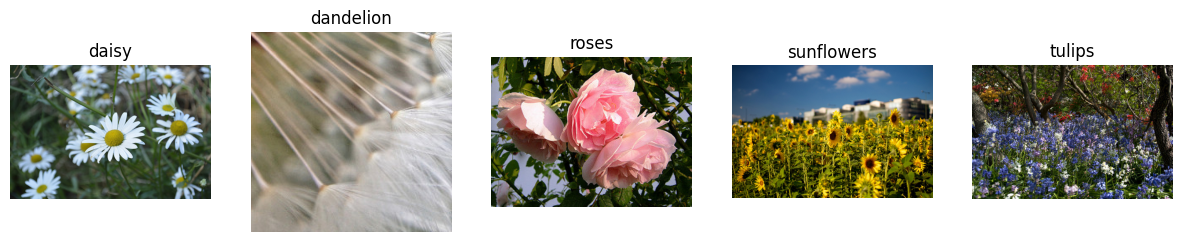

In [6]:
import random, matplotlib.pyplot as plt, matplotlib.image as mpimg
fig, axs = plt.subplots(1,5, figsize=(15,4))
classes = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root,d))])
for ax, cls in zip(axs, classes):
    imgs = [f for f in os.listdir(os.path.join(root,cls)) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    img = mpimg.imread(os.path.join(root, cls, random.choice(imgs)))
    ax.imshow(img); ax.set_title(cls); ax.axis('off')
plt.show()

In [8]:
import os, shutil, random

def make_subset(src_dir, dst_dir, per_class=100, seed=42):
    """
    Creates a new dataset with 'per_class' random images per class.
    src_dir: source dataset folder (e.g., subset_200)
    dst_dir: new folder where subset will be created
    per_class: number of images per class (default = 100)
    seed: random seed for reproducibility (default = 42)
    """
    random.seed(seed)

    # 🧹 If old subset exists, delete it to start fresh
    if os.path.exists(dst_dir):
        shutil.rmtree(dst_dir)
        print(f"🧹 Old folder '{dst_dir}' removed.")

    os.makedirs(dst_dir, exist_ok=True)

    # Loop through each class in the source dataset
    class_names = [d for d in os.listdir(src_dir)
                   if os.path.isdir(os.path.join(src_dir, d))]

    print(f"Creating new subset from: {src_dir} (Seed={seed})")
    for class_name in class_names:
        src_class = os.path.join(src_dir, class_name)
        dst_class = os.path.join(dst_dir, class_name)
        os.makedirs(dst_class, exist_ok=True)

        # Get all images in that class
        images = [f for f in os.listdir(src_class)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Randomly choose per_class images
        selected = random.sample(images, per_class)

        # Copy selected images to the new folder
        for img_name in selected:
            shutil.copy(os.path.join(src_class, img_name),
                        os.path.join(dst_class, img_name))

    print(f"✅ Subset created successfully at: {os.path.abspath(dst_dir)}")

# Run the function using your existing subset_200
make_subset("subset_200", "subset_100", per_class=100, seed=42)

🧹 Old folder 'subset_100' removed.
Creating new subset from: subset_200 (Seed=42)
✅ Subset created successfully at: C:\Users\medha\subset_100


In [9]:
import os

subset_dir = r"C:\Users\medha\subset_100"   # path to your new subset
total = 0

for root, dirs, files in os.walk(subset_dir):
    if len(files) > 0:
        class_name = os.path.basename(root)
        count = len(files)
        total += count
        print(f"{class_name:12s}: {count}")

print(f"\n✅ Total images in subset: {total}")
print(f"✅ Total classes in subset: {len(os.listdir(subset_dir))}")

daisy       : 100
dandelion   : 100
roses       : 100
sunflowers  : 100
tulips      : 100

✅ Total images in subset: 500
✅ Total classes in subset: 5


In [ ]:
#Part B

In [2]:
import tensorflow as tf
batch_size = 32
img_size = (224,224)   # for pretrained nets; for scratch CNN you can use 128

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "subset_100",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "subset_100",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 500 files belonging to 5 classes.
Using 400 files for training.
Found 500 files belonging to 5 classes.
Using 100 files for validation.


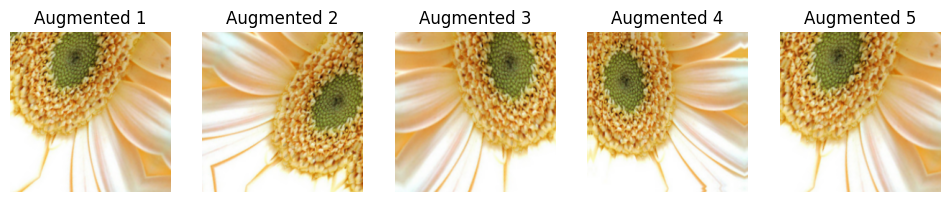

In [18]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ===========================================
# 1️⃣ Define data augmentation pipeline
# ===========================================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ===========================================
# 2️⃣ Take one image from your training dataset
# ===========================================
# Example: assuming you already created train_ds
# (e.g., using tf.keras.utils.image_dataset_from_directory)

image_batch, label_batch = next(iter(train_ds))
sample_image = image_batch[0:1]  # take 1 image (with batch dimension)

# ===========================================
# 3️⃣ Visualize 5 augmented versions
# ===========================================
plt.figure(figsize=(12, 6))
for i in range(5):
    augmented_img = data_augmentation(sample_image)
    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented_img[0].numpy().astype("uint8"))
    plt.axis("off")
    plt.title(f"Augmented {i+1}")
plt.show()




In [11]:
from tensorflow.keras import models, layers
import tensorflow as tf

# Define data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def build_scratch_cnn(input_shape=(224,224,3), num_classes=5):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),
        data_augmentation,
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_scratch_cnn()
model.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_9 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      12,845,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,939,077 (49.36 MB)

 Trainable params: 12,939,077 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # integer labels, not one-hot
    metrics=['accuracy']
)

Epoch 1/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.2475 - loss: 1.8563 - val_accuracy: 0.3800 - val_loss: 1.4416
Epoch 2/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.4075 - loss: 1.3744 - val_accuracy: 0.4700 - val_loss: 1.2147
Epoch 3/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.4250 - loss: 1.3220 - val_accuracy: 0.5300 - val_loss: 1.1404
Epoch 4/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.4975 - loss: 1.2127 - val_accuracy: 0.6000 - val_loss: 1.0694
Epoch 5/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.4850 - loss: 1.1847 - val_accuracy: 0.5800 - val_loss: 1.0633
Epoch 6/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 84s 5s/step - accuracy: 0.5375 - loss: 1.0843 - val_accuracy: 0.5300 - val_loss: 1.1658
Epoch 7/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5500 - loss: 1.1213 - val_accuracy: 0.5100 - val_loss: 1.1465
Epoch 8/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 59s 5s/step - accuracy: 0.5475 - loss: 1.0680 - val_accuracy: 0.5500 - val_loss:

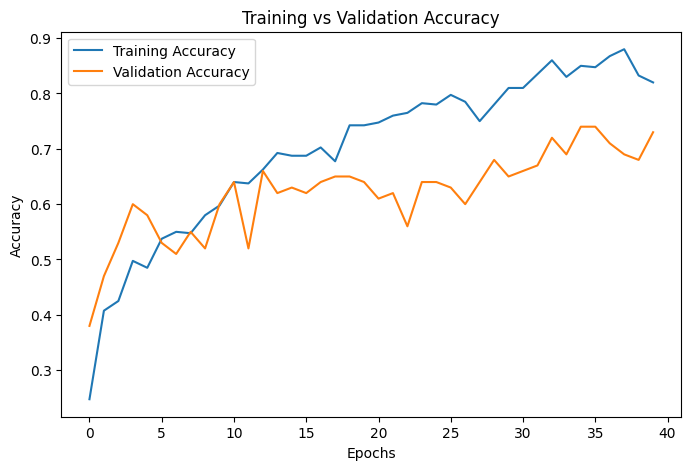

In [13]:
import matplotlib.pyplot as plt

history = model.fit(
    train_ds,             
    validation_data=val_ds,
    epochs=40             
)
# Plot accuracy curves
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [17]:
from tensorflow.keras import layers, models, applications

base_model = applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze base
base_model.trainable = False

# Add classification head
model_frozen = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

model_frozen.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_frozen.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
history_frozen = model_frozen.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.2725 - loss: 1.7810 - val_accuracy: 0.3400 - val_loss: 1.5371
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 797ms/step - accuracy: 0.4475 - loss: 1.3492 - val_accuracy: 0.4000 - val_loss: 1.4240
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5425 - loss: 1.1732 - val_accuracy: 0.4900 - val_loss: 1.3383
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 723ms/step - accuracy: 0.6450 - loss: 1.0235 - val_accuracy: 0.4800 - val_loss: 1.3012
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6675 - loss: 0.9465 - val_accuracy: 0.4900 - val_loss: 1.2404
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7050 - loss: 0.8474 - val_accuracy: 0.5200 - val_loss: 1.2344
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6950 - loss: 0.8138 - val_accuracy: 0.5400 - val_loss: 1.1907
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7400 - loss: 0.7520 - val_accuracy: 0.5500 - val_

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================================
# 1️⃣ Load Dataset (subset_100)
# ==========================================================
DATA_DIR = r"C:\Users\medha\subset_100"
IMG_SIZE = (224, 224)
BATCH = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(500).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# ==========================================================
# 2️⃣ Load Pretrained ResNet50 (Frozen)
# ==========================================================
base_model = applications.ResNet50(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # ❄ Freeze all layers

# ==========================================================
# 3️⃣ Add New Classification Head
# ==========================================================
model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

# ==========================================================
# 4️⃣ Compile & Train (Only Head)
# ==========================================================
model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

print("\n🔹 Training only classification head (ResNet50 frozen base)...\n")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Found 500 files belonging to 5 classes.
Using 400 files for training.
Found 500 files belonging to 5 classes.
Using 100 files for validation.

🔹 Training only classification head (ResNet50 frozen base)...

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.2550 - loss: 1.9368 - val_accuracy: 0.3800 - val_loss: 1.4756 - learning_rate: 5.0000e-05
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.3975 - loss: 1.4522 - val_accuracy: 0.5600 - val_loss: 1.1788 - learning_rate: 5.0000e-05
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.5200 - loss: 1.1370 - val_accuracy: 0.6700 - val_loss: 0.9352 - learning_rate: 5.0000e-05
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.6550 - loss: 0.8922 - val_accuracy: 0.7700 - val_loss: 0.7941 - learning_rate: 5.0000e-05
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.7400 - loss: 0.7609 - val_accuracy: 0.7900 - val_loss: 0.7041 - learning_rate: 5.0000e-05
Epoch 6/20
13/13 ━━━━━━━

In [2]:
# ==========================================================
# Step 12 – Fine-Tune Top 20 Layers of ResNet50
# ==========================================================
base_model.trainable = True

# Freeze all except top 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Keep BatchNormalization layers frozen for stability
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Re-compile with smaller LR (important for fine-tuning)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🔹 Fine-tuning top 20 layers of ResNet50...\n")
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)


🔹 Fine-tuning top 20 layers of ResNet50...

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.8850 - loss: 0.3408 - val_accuracy: 0.8900 - val_loss: 0.4062
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.9200 - loss: 0.2655 - val_accuracy: 0.8800 - val_loss: 0.3505
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 58s 5s/step - accuracy: 0.9550 - loss: 0.1831 - val_accuracy: 0.8900 - val_loss: 0.3167
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 59s 5s/step - accuracy: 0.9675 - loss: 0.1347 - val_accuracy: 0.9000 - val_loss: 0.3045
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 67s 5s/step - accuracy: 0.9800 - loss: 0.0959 - val_accuracy: 0.8700 - val_loss: 0.3027
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.9875 - loss: 0.0685 - val_accuracy: 0.9200 - val_loss: 0.2824
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.9850 - loss: 0.0626 - val_accuracy: 0.9000 - val_loss: 0.2668
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 58s 5s/step - accuracy: 1.0000 - lo

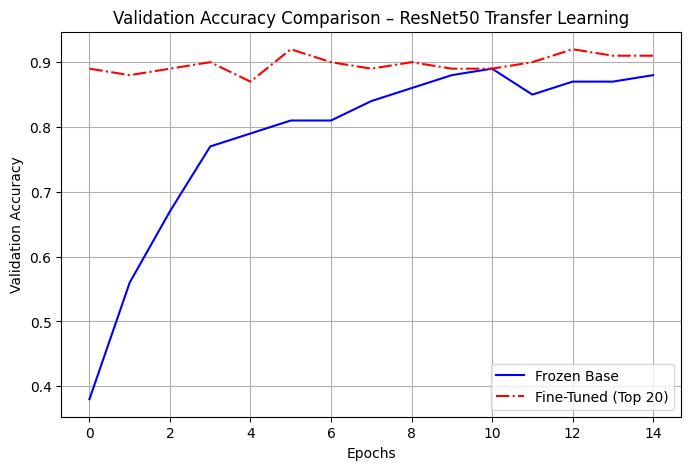

In [4]:
import matplotlib.pyplot as plt  # ✅ required import

plt.figure(figsize=(8,5))
plt.plot(history.history['val_accuracy'], 'b-', label='Frozen Base')
plt.plot(history_finetune.history['val_accuracy'], 'r-.', label='Fine-Tuned (Top 20)')
plt.title('Validation Accuracy Comparison – ResNet50 Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    "subset_200",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = image_dataset_from_directory(
    "subset_200",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)


Found 1000 files belonging to 5 classes.
Using 800 files for training.
Found 1000 files belonging to 5 classes.
Using 200 files for validation.


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================================
# 1️⃣ Load Dataset (subset_100)
# ==========================================================
DATA_DIR = r"C:\Users\medha\subset_200"
IMG_SIZE = (224, 224)
BATCH = 32



AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(500).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# ==========================================================
# 2️⃣ Load Pretrained ResNet50 (Frozen)
# ==========================================================
base_model = applications.ResNet50(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # ❄ Freeze all layers

# ==========================================================
# 3️⃣ Add New Classification Head
# ==========================================================
model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

# ==========================================================
# 4️⃣ Compile & Train (Only Head)
# ==========================================================
model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

print("\n🔹 Training only classification head (ResNet50 frozen base)...\n")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


🔹 Training only classification head (ResNet50 frozen base)...

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.2725 - loss: 1.9886 - val_accuracy: 0.5350 - val_loss: 1.2120 - learning_rate: 5.0000e-05
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.5038 - loss: 1.2905 - val_accuracy: 0.7200 - val_loss: 0.8383 - learning_rate: 5.0000e-05
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.6525 - loss: 0.9255 - val_accuracy: 0.7950 - val_loss: 0.6729 - learning_rate: 5.0000e-05
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.7375 - loss: 0.7617 - val_accuracy: 0.8250 - val_loss: 0.5923 - learning_rate: 5.0000e-05
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.7713 - loss: 0.6575 - val_accuracy: 0.8550 - val_loss: 0.5347 - learning_rate: 5.0000e-05
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.7900 - loss: 0.5964 - val_accuracy: 0.8700 - val_loss: 0.5012 - learning_rate: 5.0000e-05
Epoch 7/20
2

In [7]:
# ==========================================================
# Step 12 – Fine-Tune Top 20 Layers of ResNet50
# ==========================================================
base_model.trainable = True

# Freeze all except top 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Keep BatchNormalization layers frozen for stability
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Re-compile with smaller LR (important for fine-tuning)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🔹 Fine-tuning top 20 layers of ResNet50...\n")
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12
)


🔹 Fine-tuning top 20 layers of ResNet50...

Epoch 1/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 100s 4s/step - accuracy: 0.8550 - loss: 0.3945 - val_accuracy: 0.8650 - val_loss: 0.4232
Epoch 2/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.9112 - loss: 0.2836 - val_accuracy: 0.8650 - val_loss: 0.3951
Epoch 3/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 178s 7s/step - accuracy: 0.9312 - loss: 0.2078 - val_accuracy: 0.8750 - val_loss: 0.3920
Epoch 4/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 97s 4s/step - accuracy: 0.9475 - loss: 0.1605 - val_accuracy: 0.8850 - val_loss: 0.3856
Epoch 5/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 399s 16s/step - accuracy: 0.9712 - loss: 0.1100 - val_accuracy: 0.8800 - val_loss: 0.3794
Epoch 6/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.9837 - loss: 0.0694 - val_accuracy: 0.8700 - val_loss: 0.3759
Epoch 7/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 560s 21s/step - accuracy: 0.9850 - loss: 0.0578 - val_accuracy: 0.8900 - val_loss: 0.3815
Epoch 8/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.997

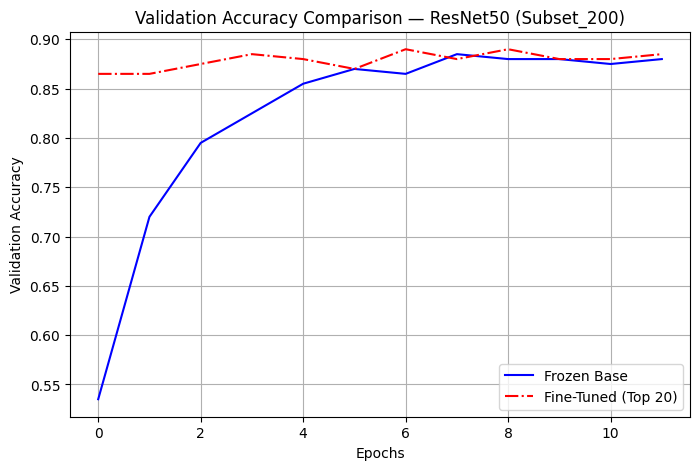

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['val_accuracy'], 'b-', label='Frozen Base')
plt.plot(history_finetune.history['val_accuracy'], 'r-.', label='Fine-Tuned (Top 20)')
plt.title('Validation Accuracy Comparison — ResNet50 (Subset_200)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [16]:
import os

# Example for one model
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

# Calculate model size in MB
model.save("temp_model.keras")
model_size = os.path.getsize("temp_model.keras") / (1024 * 1024)  # MB

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Model Size: {model_size:.2f} MB")


Training Accuracy: 0.8988
Validation Accuracy: 0.8800
Model Size: 164.68 MB


In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================================
# 1️⃣ Load Dataset (subset_100)
# ==========================================================
DATA_DIR = r"C:\Users\medha\subset_100"
IMG_SIZE = (224, 224)
BATCH = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(500).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# ==========================================================
# 2️⃣ Load Pretrained ResNet50 (Frozen)
# ==========================================================
base_model_100 = applications.ResNet50(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model_100.trainable = False   # ❄ Freeze all layers

# ==========================================================
# 3️⃣ Add New Classification Head
# ==========================================================
model_100=models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    base_model_100,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

# ==========================================================
# 4️⃣ Compile & Train (Only Head)
# ==========================================================
model_100.compile(
    optimizer=optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

print("\n🔹 Training only classification head (ResNet50 frozen base)...\n")
history_100_frozen = model_100.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Found 500 files belonging to 5 classes.
Using 400 files for training.
Found 500 files belonging to 5 classes.
Using 100 files for validation.

🔹 Training only classification head (ResNet50 frozen base)...

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 89s 6s/step - accuracy: 0.2725 - loss: 2.0223 - val_accuracy: 0.3600 - val_loss: 1.4443 - learning_rate: 5.0000e-05
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 67s 5s/step - accuracy: 0.3875 - loss: 1.5099 - val_accuracy: 0.5900 - val_loss: 1.1375 - learning_rate: 5.0000e-05
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 914s 75s/step - accuracy: 0.5400 - loss: 1.1949 - val_accuracy: 0.7300 - val_loss: 0.9054 - learning_rate: 5.0000e-05
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 73s 5s/step - accuracy: 0.6600 - loss: 0.9304 - val_accuracy: 0.7800 - val_loss: 0.7733 - learning_rate: 5.0000e-05
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 76s 5s/step - accuracy: 0.7350 - loss: 0.7570 - val_accuracy: 0.8300 - val_loss: 0.6757 - learning_rate: 5.0000e-05
Epoch 6/20
13/13 ━━━━━

In [21]:
# Step 12 – Fine-Tune Top 20 Layers of ResNet50
# ==========================================================
base_model_100.trainable = True

# Freeze all except top 20 layers
for layer in base_model_100.layers[:-20]:
    layer.trainable = False

# Keep BatchNormalization layers frozen for stability
for layer in base_model_100.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Re-compile with smaller LR (important for fine-tuning)
model_100.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🔹 Fine-tuning top 20 layers of ResNet50...\n")
history_finetune_100 = model_100.fit(
    train_ds,
    validation_data=val_ds,
    epochs=11
)


🔹 Fine-tuning top 20 layers of ResNet50...

Epoch 1/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 110s 7s/step - accuracy: 0.8350 - loss: 0.5068 - val_accuracy: 0.8900 - val_loss: 0.4666
Epoch 2/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 129s 6s/step - accuracy: 0.8800 - loss: 0.3589 - val_accuracy: 0.8800 - val_loss: 0.4111
Epoch 3/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - accuracy: 0.9000 - loss: 0.2956 - val_accuracy: 0.8800 - val_loss: 0.3934
Epoch 4/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 78s 6s/step - accuracy: 0.9400 - loss: 0.2093 - val_accuracy: 0.9100 - val_loss: 0.3329
Epoch 5/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 85s 7s/step - accuracy: 0.9525 - loss: 0.1513 - val_accuracy: 0.9200 - val_loss: 0.3283
Epoch 6/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - accuracy: 0.9750 - loss: 0.1011 - val_accuracy: 0.8900 - val_loss: 0.3279
Epoch 7/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 78s 6s/step - accuracy: 0.9725 - loss: 0.0984 - val_accuracy: 0.9000 - val_loss: 0.3167
Epoch 8/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - accuracy: 0.9950 - 

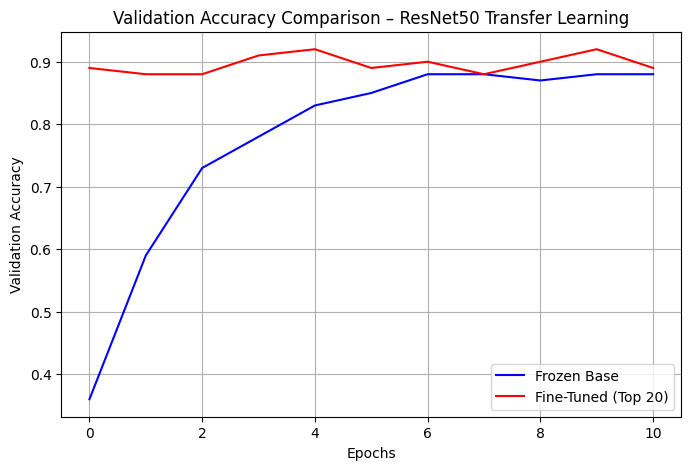

In [22]:
plt.figure(figsize=(8,5))
plt.plot(history_100_frozen.history['val_accuracy'], 'b-', label='Frozen Base')
plt.plot(history_finetune_100.history['val_accuracy'], 'r-', label='Fine-Tuned (Top 20)')
plt.title('Validation Accuracy Comparison – ResNet50 Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================================================
# 1️⃣ Load Dataset (subset_100)
# ==========================================================
DATA_DIR = r"C:\Users\medha\subset_200"
IMG_SIZE = (224, 224)
BATCH = 32

train_ds_200 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)
val_ds_200 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_200 = train_ds_200.cache().shuffle(500).prefetch(AUTOTUNE)
val_ds_200 = val_ds_200.cache().prefetch(AUTOTUNE)

# ==========================================================
# 2️⃣ Load Pretrained ResNet50 (Frozen)
# ==========================================================
base_model_200 = applications.ResNet50(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model_200.trainable = False   # ❄ Freeze all layers

# ==========================================================
# 3️⃣ Add New Classification Head
# ==========================================================
model_200=models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    base_model_200,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

# ==========================================================
# 4️⃣ Compile & Train (Only Head)
# ==========================================================
model_200.compile(
    optimizer=optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

print("\n🔹 Training only classification head (ResNet50 frozen base)...\n")
history_200_frozen = model_200.fit(
    train_ds_200,
    validation_data=val_ds_200,
    epochs=20,
    callbacks=callbacks
)

Found 1000 files belonging to 5 classes.
Using 800 files for training.
Found 1000 files belonging to 5 classes.
Using 200 files for validation.

🔹 Training only classification head (ResNet50 frozen base)...

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 165s 6s/step - accuracy: 0.2788 - loss: 1.9707 - val_accuracy: 0.5000 - val_loss: 1.3139 - learning_rate: 5.0000e-05
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 182s 5s/step - accuracy: 0.5263 - loss: 1.2755 - val_accuracy: 0.6800 - val_loss: 0.9348 - learning_rate: 5.0000e-05
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 156s 6s/step - accuracy: 0.6400 - loss: 0.9762 - val_accuracy: 0.7400 - val_loss: 0.7466 - learning_rate: 5.0000e-05
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 202s 6s/step - accuracy: 0.7138 - loss: 0.7608 - val_accuracy: 0.7850 - val_loss: 0.6396 - learning_rate: 5.0000e-05
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 202s 6s/step - accuracy: 0.7725 - loss: 0.6397 - val_accuracy: 0.8000 - val_loss: 0.5763 - learning_rate: 5.0000e-05
Epoch 6/20
25/25 

In [2]:
# ==========================================================
# Step 12 – Fine-Tune Top 20 Layers of ResNet50
# ==========================================================
base_model_200.trainable = True

# Freeze all except top 20 layers
for layer in base_model_200.layers[:-20]:
    layer.trainable = False

# Keep BatchNormalization layers frozen for stability
for layer in base_model_200.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Re-compile with smaller LR (important for fine-tuning)
model_200.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🔹 Fine-tuning top 20 layers of ResNet50...\n")
history_finetune = model_200.fit(
    train_ds_200,
    validation_data=val_ds_200,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3)
    ]
)


🔹 Fine-tuning top 20 layers of ResNet50...

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 187s 7s/step - accuracy: 0.9513 - loss: 0.1816 - val_accuracy: 0.8450 - val_loss: 0.3844 - learning_rate: 1.0000e-05
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 199s 7s/step - accuracy: 0.9762 - loss: 0.1055 - val_accuracy: 0.8650 - val_loss: 0.3734 - learning_rate: 1.0000e-05
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 235s 8s/step - accuracy: 0.9712 - loss: 0.1011 - val_accuracy: 0.8500 - val_loss: 0.4031 - learning_rate: 1.0000e-05
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 200s 7s/step - accuracy: 0.9912 - loss: 0.0610 - val_accuracy: 0.8650 - val_loss: 0.3589 - learning_rate: 1.0000e-05
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 189s 6s/step - accuracy: 0.9825 - loss: 0.0540 - val_accuracy: 0.8650 - val_loss: 0.3922 - learning_rate: 1.0000e-05
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 217s 7s/step - accuracy: 0.9987 - loss: 0.0284 - val_accuracy: 0.8700 - val_loss: 0.3912 - learning_rate: 1.0000e-05
Epoch 7/20
25/25 ━━━━━━━━

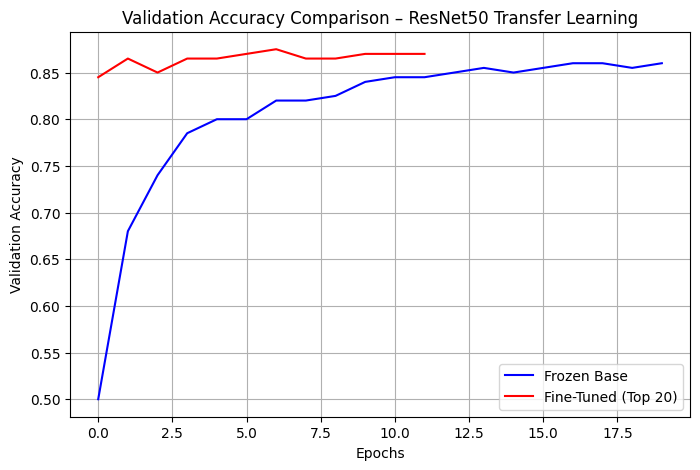

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_200_frozen.history['val_accuracy'], 'b-', label='Frozen Base')
plt.plot(history_finetune.history['val_accuracy'], 'r-', label='Fine-Tuned (Top 20)')
plt.title('Validation Accuracy Comparison – ResNet50 Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# ==========================================================
# 1️⃣ Define dataset directory and parameters
# ==========================================================
DATA_DIR = r"C:\Users\medha\subset_200"  # 🔹 change this path to your dataset root folder
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

# ==========================================================
# 2️⃣ Create train, validation, and test datasets
# ==========================================================
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Optional: Create a smaller test set from validation (if no separate folder)
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print("✅ Datasets prepared:")
print(f"Train batches: {len(train_ds)}")
print(f"Val batches:   {len(val_ds)}")
print(f"Test batches:  {len(test_ds)}")

Found 1000 files belonging to 5 classes.
Using 800 files for training.
Found 1000 files belonging to 5 classes.
Using 200 files for validation.
✅ Datasets prepared:
Train batches: 25
Val batches:   4
Test batches:  3


In [32]:
import os
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

history_finetune_100 = model_100.fit(
    train_ds,
    validation_data=val_ds,
    epochs=11
)

history_finetune = model_200.fit(
    train_ds_200,
    validation_data=val_ds_200,
    epochs=20,
   
)


model_100.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("\n🔹 Training only classification head (ResNet50 frozen base)...\n")
history_100_frozen = model_100.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)
def model_size_mb(model):
    model.save("tmp.keras", overwrite=True)
    return os.path.getsize("tmp.keras") / 1e6

experiments = {
    "Subset 100 (Frozen)": [history_100_frozen, model_100],
    "Subset 100 (Fine-tuned)": [history_finetune_100, model_100],
    "Subset 200 (Frozen)": [history_200_frozen, model_200],
    "Subset 200 (Fine-tuned)": [history_finetune_200, model_200],
}

# Collect results
results = []
for name, (hist, mod) in experiments.items():
    train_acc = hist.history['accuracy'][-1]
    val_acc = hist.history['val_accuracy'][-1]
    size = model_size_mb(mod)
    results.append([name, f"{train_acc:.4f}", f"{val_acc:.4f}", f"{size:.2f} MB"])

# Print header
print("\n📊 Model Performance Summary\n")
print(f"{'Experiment':<28}{'Train Acc':<15}{'Val Acc':<15}{'Model Size':<12}")
print("-" * 70)

# Print each row
for row in results:
    print(f"{row[0]:<28}{row[1]:<15}{row[2]:<15}{row[3]:<12}")

Epoch 1/11
25/25 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step - accuracy: 0.7887 - loss: 0.6255 - val_accuracy: 0.7308 - val_loss: 0.7383
Epoch 2/11
25/25 ━━━━━━━━━━━━━━━━━━━━ 141s 5s/step - accuracy: 0.7575 - loss: 0.6945 - val_accuracy: 0.7404 - val_loss: 0.7411
Epoch 3/11
25/25 ━━━━━━━━━━━━━━━━━━━━ 140s 5s/step - accuracy: 0.7713 - loss: 0.6866 - val_accuracy: 0.7308 - val_loss: 0.6884
Epoch 4/11
25/25 ━━━━━━━━━━━━━━━━━━━━ 142s 5s/step - accuracy: 0.7763 - loss: 0.6537 - val_accuracy: 0.7692 - val_loss: 0.6966
Epoch 5/11
25/25 ━━━━━━━━━━━━━━━━━━━━ 143s 5s/step - accuracy: 0.7825 - loss: 0.6471 - val_accuracy: 0.8365 - val_loss: 0.5999
Epoch 6/11
25/25 ━━━━━━━━━━━━━━━━━━━━ 141s 5s/step - accuracy: 0.7763 - loss: 0.6614 - val_accuracy: 0.7788 - val_loss: 0.7326
Epoch 7/11
25/25 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step - accuracy: 0.7837 - loss: 0.6544 - val_accuracy: 0.7308 - val_loss: 0.7598
Epoch 8/11
25/25 ━━━━━━━━━━━━━━━━━━━━ 138s 5s/step - accuracy: 0.7788 - loss: 0.6467 - val_accuracy: 0.7788 - v

NameError: name 'history_finetune_200' is not defined

In [1]:
# ==========================================================
# Step 12 – Fine-Tune Top 20 Layers of ResNet50
# ==========================================================
base_model_200.trainable = True

# Freeze all except top 20 layers
for layer in base_model_200.layers[:-20]:
    layer.trainable = False

# Keep BatchNormalization layers frozen for stability
for layer in base_model_200.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Re-compile with smaller LR (important for fine-tuning)
model_200.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🔹 Fine-tuning top 20 layers of ResNet50...\n")
history_finetune = model_200.fit(
    train_ds_200,
    validation_data=val_ds_200,
    epochs=20
)

NameError: name 'base_model_200' is not defined

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================================================
# 1️⃣ Load Dataset (subset_100)
# ==========================================================
DATA_DIR = r"C:\Users\medha\subset_200"
IMG_SIZE = (224, 224)
BATCH = 32

train_ds_200 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)
val_ds_200 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_200 = train_ds_200.cache().shuffle(500).prefetch(AUTOTUNE)
val_ds_200 = val_ds_200.cache().prefetch(AUTOTUNE)

# ==========================================================
# 2️⃣ Load Pretrained ResNet50 (Frozen)
# ==========================================================
base_model_200 = applications.ResNet50(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model_200.trainable = False   # ❄ Freeze all layers

# ==========================================================
# 3️⃣ Add New Classification Head
# ==========================================================
model_200=models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    base_model_200,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

# ==========================================================
# 4️⃣ Compile & Train (Only Head)
# ==========================================================
model_200.compile(
    optimizer=optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

print("\n🔹 Training only classification head (ResNet50 frozen base)...\n")
history_200_frozen = model_200.fit(
    train_ds_200,
    validation_data=val_ds_200,
    epochs=20,
    callbacks=callbacks
)

Found 1000 files belonging to 5 classes.
Using 800 files for training.
Found 1000 files belonging to 5 classes.
Using 200 files for validation.

🔹 Training only classification head (ResNet50 frozen base)...

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 154s 6s/step - accuracy: 0.3363 - loss: 1.6862 - val_accuracy: 0.6000 - val_loss: 1.0805 - learning_rate: 5.0000e-05
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 134s 5s/step - accuracy: 0.5638 - loss: 1.1056 - val_accuracy: 0.8000 - val_loss: 0.7447 - learning_rate: 5.0000e-05
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 133s 5s/step - accuracy: 0.7013 - loss: 0.8465 - val_accuracy: 0.8200 - val_loss: 0.6103 - learning_rate: 5.0000e-05
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 143s 5s/step - accuracy: 0.7500 - loss: 0.7012 - val_accuracy: 0.8450 - val_loss: 0.5350 - learning_rate: 5.0000e-05
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 141s 5s/step - accuracy: 0.8000 - loss: 0.5782 - val_accuracy: 0.8500 - val_loss: 0.4976 - learning_rate: 5.0000e-05
Epoch 6/20
25/25 

In [3]:
# ==========================================================
# Step 12 – Fine-Tune Top 20 Layers of ResNet50
# ==========================================================
base_model_200.trainable = True

# Freeze all except top 20 layers
for layer in base_model_200.layers[:-20]:
    layer.trainable = False

# Keep BatchNormalization layers frozen for stability
for layer in base_model_200.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Re-compile with smaller LR (important for fine-tuning)
model_200.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🔹 Fine-tuning top 20 layers of ResNet50...\n")
history_finetune_200= model_200.fit(
    train_ds_200,
    validation_data=val_ds_200,
    epochs=15
)


🔹 Fine-tuning top 20 layers of ResNet50...

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 189s 7s/step - accuracy: 0.9125 - loss: 0.2869 - val_accuracy: 0.8750 - val_loss: 0.3795
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 169s 7s/step - accuracy: 0.9475 - loss: 0.1949 - val_accuracy: 0.8750 - val_loss: 0.3597
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 171s 7s/step - accuracy: 0.9638 - loss: 0.1346 - val_accuracy: 0.8700 - val_loss: 0.3842
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 174s 6s/step - accuracy: 0.9762 - loss: 0.0992 - val_accuracy: 0.8750 - val_loss: 0.3590
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9825 - loss: 0.0684 - val_accuracy: 0.8850 - val_loss: 0.3754
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.9887 - loss: 0.0548 - val_accuracy: 0.8750 - val_loss: 0.3971
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.9862 - loss: 0.0481 - val_accuracy: 0.8900 - val_loss: 0.3745
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.9937

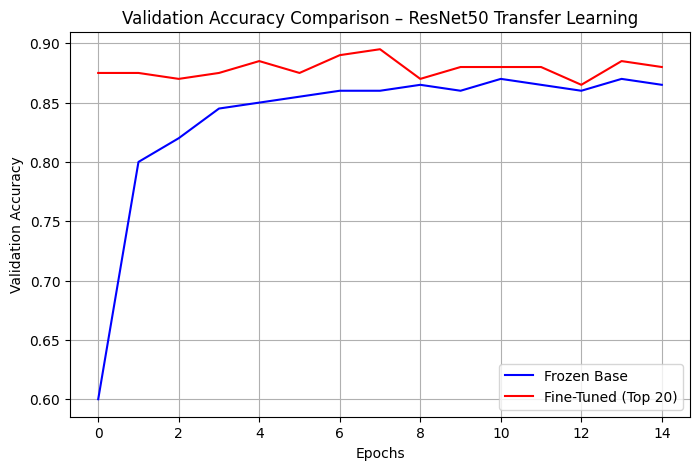

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_200_frozen.history['val_accuracy'], 'b-', label='Frozen Base')
plt.plot(history_finetune_200.history['val_accuracy'], 'r-', label='Fine-Tuned (Top 20)')
plt.title('Validation Accuracy Comparison – ResNet50 Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
import os

def model_size_mb(model):
    model.save("tmp.keras", overwrite=True)
    return os.path.getsize("tmp.keras") / 1e6

experiments = {
    "Subset 100 (Frozen)": [history_100_frozen, model_100],
    "Subset 100 (Fine-tuned)": [history_finetune_100, model_100],
    "Subset 200 (Frozen)": [history_200_frozen, model_200],
    "Subset 200 (Fine-tuned)": [history_finetune_200, model_200],
}

# Collect results
results = []
for name, (hist, mod) in experiments.items():
    train_acc = hist.history['accuracy'][-1]
    val_acc = hist.history['val_accuracy'][-1]
    size = model_size_mb(mod)
    results.append([name, f"{train_acc:.4f}", f"{val_acc:.4f}", f"{size:.2f} MB"])

# Print header
print("\n📊 Model Performance Summary\n")
print(f"{'Experiment':<28}{'Train Acc':<15}{'Val Acc':<15}{'Model Size':<12}")
print("-" * 70)

# Print each row
for row in results:
    print(f"{row[0]:<28}{row[1]:<15}{row[2]:<15}{row[3]:<12}")

NameError: name 'history_100_frozen' is not defined

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================================================
# 1️⃣ Load Dataset (subset_100)
# ==========================================================
DATA_DIR = r"C:\Users\medha\subset_100"
IMG_SIZE = (224, 224)
BATCH = 32

train_ds_100 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)
val_ds_100 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_100 = train_ds_100.cache().shuffle(500).prefetch(AUTOTUNE)
val_ds_100 = val_ds_100.cache().prefetch(AUTOTUNE)

# ==========================================================
# 2️⃣ Load Pretrained ResNet50 (Frozen)
# ==========================================================
base_model_100 = applications.ResNet50(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model_100.trainable = False   # ❄ Freeze all layers

# ==========================================================
# 3️⃣ Add New Classification Head
# ==========================================================
model_100=models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    base_model_100,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

# ==========================================================
# 4️⃣ Compile & Train (Only Head)
# ==========================================================
model_100.compile(
    optimizer=optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

print("\n🔹 Training only classification head (ResNet50 frozen base)...\n")
history_100_frozen = model_100.fit(
    train_ds_100,
    validation_data=val_ds_100,
    epochs=20,
    callbacks=callbacks
)

Found 500 files belonging to 5 classes.
Using 400 files for training.
Found 500 files belonging to 5 classes.
Using 100 files for validation.

🔹 Training only classification head (ResNet50 frozen base)...

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.2350 - loss: 2.0721 - val_accuracy: 0.4400 - val_loss: 1.5080 - learning_rate: 5.0000e-05
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.4275 - loss: 1.5416 - val_accuracy: 0.5700 - val_loss: 1.1909 - learning_rate: 5.0000e-05
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.5875 - loss: 1.1044 - val_accuracy: 0.6700 - val_loss: 0.9714 - learning_rate: 5.0000e-05
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.6425 - loss: 0.9502 - val_accuracy: 0.6900 - val_loss: 0.8365 - learning_rate: 5.0000e-05
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.6750 - loss: 0.8741 - val_accuracy: 0.7600 - val_loss: 0.7414 - learning_rate: 5.0000e-05
Epoch 6/20
13/13 ━━━━━━━

In [8]:
# ==========================================================
# Step 12 – Fine-Tune Top 20 Layers of ResNet50
# ==========================================================
base_model_100.trainable = True

# Freeze all except top 20 layers
for layer in base_model_100.layers[:-20]:
    layer.trainable = False

# Keep BatchNormalization layers frozen for stability
for layer in base_model_100.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Re-compile with smaller LR (important for fine-tuning)
model_100.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🔹 Fine-tuning top 20 layers of ResNet50...\n")
history_finetune_100= model_100.fit(
    train_ds_100,
    validation_data=val_ds_100,
    epochs=12
)


🔹 Fine-tuning top 20 layers of ResNet50...

Epoch 1/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.8425 - loss: 0.4704 - val_accuracy: 0.8700 - val_loss: 0.4673
Epoch 2/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.9050 - loss: 0.3379 - val_accuracy: 0.8600 - val_loss: 0.4085
Epoch 3/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.9425 - loss: 0.2544 - val_accuracy: 0.8700 - val_loss: 0.3561
Epoch 4/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.9575 - loss: 0.1781 - val_accuracy: 0.8800 - val_loss: 0.3192
Epoch 5/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.9800 - loss: 0.1137 - val_accuracy: 0.8600 - val_loss: 0.3133
Epoch 6/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.9750 - loss: 0.1134 - val_accuracy: 0.8800 - val_loss: 0.2999
Epoch 7/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.9900 - loss: 0.0637 - val_accuracy: 0.8800 - val_loss: 0.2885
Epoch 8/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.9900 - lo

In [9]:
import os

def model_size_mb(model):
    model.save("tmp.keras", overwrite=True)
    return os.path.getsize("tmp.keras") / 1e6

experiments = {
    "Subset 100 (Frozen)": [history_100_frozen, model_100],
    "Subset 100 (Fine-tuned)": [history_finetune_100, model_100],
    "Subset 200 (Frozen)": [history_200_frozen, model_200],
    "Subset 200 (Fine-tuned)": [history_finetune_200, model_200],
}

# Collect results
results = []
for name, (hist, mod) in experiments.items():
    train_acc = hist.history['accuracy'][-1]
    val_acc = hist.history['val_accuracy'][-1]
    size = model_size_mb(mod)
    results.append([name, f"{train_acc:.4f}", f"{val_acc:.4f}", f"{size:.2f} MB"])

# Print header
print("\n📊 Model Performance Summary\n")
print(f"{'Experiment':<28}{'Train Acc':<15}{'Val Acc':<15}{'Model Size':<12}")
print("-" * 70)

# Print each row
for row in results:
    print(f"{row[0]:<28}{row[1]:<15}{row[2]:<15}{row[3]:<12}")
    


📊 Model Performance Summary

Experiment                  Train Acc      Val Acc        Model Size  
----------------------------------------------------------------------
Subset 100 (Frozen)         0.8900         0.8500         172.68 MB   
Subset 100 (Fine-tuned)     0.9975         0.8900         172.68 MB   
Subset 200 (Frozen)         0.9525         0.8650         172.68 MB   
Subset 200 (Fine-tuned)     0.9987         0.8800         172.68 MB   


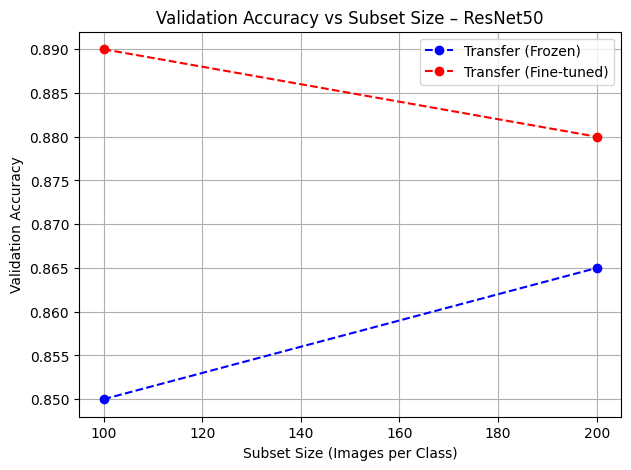

In [10]:
import matplotlib.pyplot as plt

subset_sizes = [100, 200]
val_acc_frozen = [
    history_100_frozen.history['val_accuracy'][-1],
    history_200_frozen.history['val_accuracy'][-1],
]
val_acc_finetune = [
    history_finetune_100.history['val_accuracy'][-1],
    history_finetune_200.history['val_accuracy'][-1],
]

plt.figure(figsize=(7,5))
plt.plot(subset_sizes, val_acc_frozen, 'bo--', label='Transfer (Frozen)')
plt.plot(subset_sizes, val_acc_finetune, 'ro--', label='Transfer (Fine-tuned)')
# optionally add “Scratch”
# plt.plot(subset_sizes, val_acc_scratch, 'go--', label='Scratch')

plt.title('Validation Accuracy vs Subset Size – ResNet50')
plt.xlabel('Subset Size (Images per Class)')
plt.ylabel('Validation Accuracy')
plt.legend(); plt.grid(True); plt.show()

In [20]:
DATA_DIR_200 = r"C:\Users\medha\subset_200"
IMG_SIZE = (224, 224)
BATCH = 32

# Load dataset (before caching)
train_ds_200 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR_200,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)
val_ds_200 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR_200,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

# ✅ Save class names BEFORE caching/prefetching
class_names = val_ds_200.class_names
print("Class names:", class_names)

# Now apply caching/prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds_200 = train_ds_200.cache().shuffle(500).prefetch(AUTOTUNE)
val_ds_200 = val_ds_200.cache().prefetch(AUTOTUNE)


Found 1000 files belonging to 5 classes.
Using 800 files for training.
Found 1000 files belonging to 5 classes.
Using 200 files for validation.
Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step


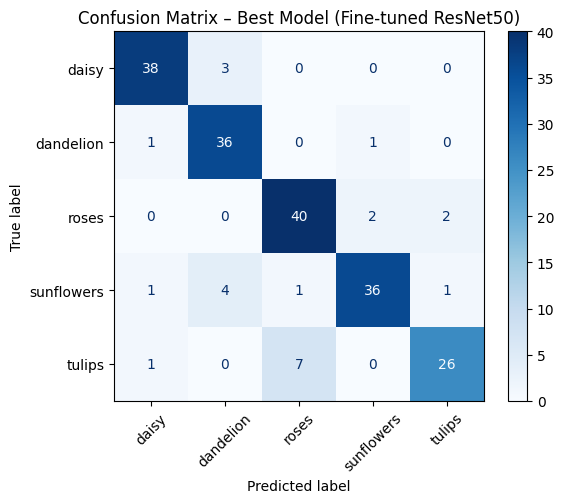

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Assume best_model = model_200 (fine-tuned ResNet50)
best_model = model_200

# Collect validation data
val_images, val_labels = [], []
for images, labels in val_ds_200:
    val_images.append(images)
    val_labels.append(labels)
val_images = np.concatenate(val_images)
val_labels = np.concatenate(val_labels)

# Predictions
pred_probs = best_model.predict(val_images)
pred_labels = np.argmax(pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(val_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix – Best Model (Fine-tuned ResNet50)")
plt.show()


In [27]:
# Save
best_model.save("best_flower_model.keras")
print("✅ Model saved as best_flower_model.keras")

# Load & Predict a new flower image
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"C:\Users\medha\Downloads\photo_detect.jpg"  # change path
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)



pred = best_model.predict(img_array)
predicted_class = class_names_200[np.argmax(pred)]
print(f"\n🌸 Predicted class: {predicted_class}")

✅ Model saved as best_flower_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step

🌸 Predicted class: tulips


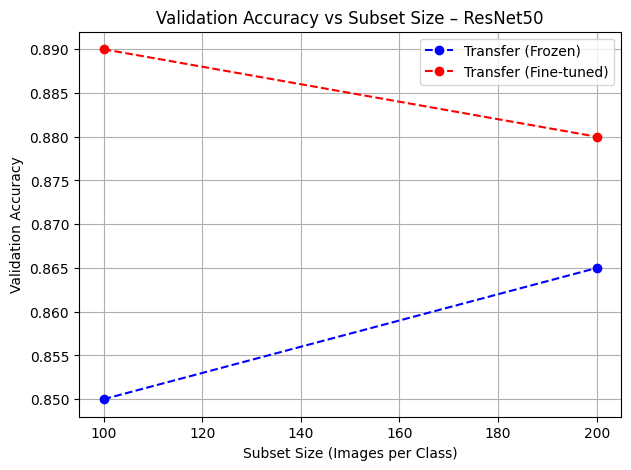

In [30]:
import matplotlib.pyplot as plt

subset_sizes = [100, 200]
val_acc_frozen = [
    history_100_frozen.history['val_accuracy'][-1],
    history_200_frozen.history['val_accuracy'][-1],
]
val_acc_finetune = [
    history_finetune_100.history['val_accuracy'][-1],
    history_finetune_200.history['val_accuracy'][-1],
]

plt.figure(figsize=(7,5))
plt.plot(subset_sizes, val_acc_frozen, 'bo--', label='Transfer (Frozen)')
plt.plot(subset_sizes, val_acc_finetune, 'ro--', label='Transfer (Fine-tuned)')
# optionally add “Scratch”
# plt.plot(subset_sizes, val_acc_scratch, 'go--', label='Scratch')

plt.title('Validation Accuracy vs Subset Size – ResNet50')
plt.xlabel('Subset Size (Images per Class)')
plt.ylabel('Validation Accuracy')
plt.legend(); plt.grid(True); plt.show()

In [31]:
# Save
best_model.save("best_flower_model.keras")
print("✅ Model saved as best_flower_model.keras")

# Load & Predict a new flower image
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"C:\Users\medha\Downloads\roonz-nl-ATgfRqpFfFI-unsplash.jpg"  # change path
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)



pred = best_model.predict(img_array)
predicted_class = class_names_200[np.argmax(pred)]
print(f"\n🌸 Predicted class: {predicted_class}")

✅ Model saved as best_flower_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step

🌸 Predicted class: tulips


In [ ]:
# Save
best_model.save("best_flower_model.keras")
print("✅ Model saved as best_flower_model.keras")

# Load & Predict a new flower image
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"C:\Users\medha\Downloads\roonz-nl-ATgfRqpFfFI-unsplash.jpg"  # change path
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)



pred = best_model.predict(img_array)
predicted_class = class_names_200[np.argmax(pred)]
print(f"\n🌸 Predicted class: {predicted_class}")